# 任务4第二部分：加入空间结构特征后的XGBoost重训练

对比两个模型：

- 基准模型：论文原始6个特征
- 新模型：原始6个特征 + 8个空间结构特征

两者使用完全相同的240组随机划分、728/128训练测试数量和XGBoost参数。

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

DATA_FILE = Path('model_input_6_plus_spatial_856.csv')
RESULT_DIR = Path('task4_spatial_results')
RESULT_DIR.mkdir(exist_ok=True)

N_RUNS = 240
SEEDS = list(range(N_RUNS))
TEST_SIZE = 128
LN10 = np.log(10)


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(f'找不到文件：{DATA_FILE.resolve()}')

df = pd.read_csv(DATA_FILE)
print('数据形状：', df.shape)
print('缺失值总数：', int(df.isna().sum().sum()))
display(df.head())


数据形状： (856, 21)
缺失值总数： 0


,model_row,Old_index_1,smiles,canonical_smiles,doi,compoundId,Conju-Max-Distance,Wavelength (Exp nm),ET(30) (Solvent),PEOE-Charge-Max,...,Atomic-MR-Max,rg,asphericity,eccentricity,num_chiral_centers,num_cis_trans,rg_mw_ratio,molecular_weight,rigid_bond_ratio,values_ln
0,0,1,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2a,10,750,37.4,0.285785,...,26.486,4.209492,0.242658,0.915303,0,0,0.009736,432.376,0.135135,3.871201
1,1,2,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2b,11,760,37.4,0.285785,...,26.486,4.353599,0.268298,0.926502,0,0,0.009667,450.366,0.131579,3.828641
2,2,3,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.037,2c,11,750,37.4,0.285785,...,26.486,4.533366,0.269609,0.927593,0,0,0.009711,466.821,0.131579,4.477337
3,3,5,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.039,2e,11,750,37.4,0.285785,...,26.486,4.512181,0.271346,0.927907,0,0,0.009758,462.402,0.128205,3.713572
4,4,6,CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]2(c2...,CAN:CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]...,10.1016/j.jorganchem.2013.12.040,2f,11,740,37.4,0.285785,...,26.486,4.850971,0.365411,0.955132,0,0,0.009635,503.499,0.119048,3.988984


In [3]:
BASE_FEATURES = [
    'Conju-Max-Distance',
    'Wavelength (Exp nm)',
    'ET(30) (Solvent)',
    'PEOE-Charge-Max',
    'Atomic-LogP-Min',
    'Atomic-MR-Max',
]

SPATIAL_FEATURES = [
    'rg',
    'asphericity',
    'eccentricity',
    'num_chiral_centers',
    'num_cis_trans',
    'rg_mw_ratio',
    'molecular_weight',
    'rigid_bond_ratio',
]

TARGET = 'values_ln'

required = BASE_FEATURES + SPATIAL_FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f'缺少列：{missing}')

print('基准特征：', BASE_FEATURES)
print('新增空间特征：', SPATIAL_FEATURES)


基准特征： ['Conju-Max-Distance', 'Wavelength (Exp nm)', 'ET(30) (Solvent)', 'PEOE-Charge-Max', 'Atomic-LogP-Min', 'Atomic-MR-Max']
新增空间特征： ['rg', 'asphericity', 'eccentricity', 'num_chiral_centers', 'num_cis_trans', 'rg_mw_ratio', 'molecular_weight', 'rigid_bond_ratio']


In [4]:
XGB_PARAMS = dict(
    n_estimators=150,
    learning_rate=0.025,
    max_depth=13,
    verbosity=0,
    booster='gbtree',
    reg_alpha=np.exp(-6.788644799030888),
    reg_lambda=np.exp(-7.450413274554533),
    gamma=np.exp(-5.374463422208394),
    subsample=0.5,
    objective='reg:squarederror',
    n_jobs=-1,
)

def run_model(feature_names, model_name):
    X = df[feature_names].astype(float)
    y = df[TARGET].astype(float)
    indices = np.arange(len(df))
    rows = []
    pred_sum = np.zeros(len(df), dtype=float)
    pred_count = np.zeros(len(df), dtype=int)

    for seed in SEEDS:
        train_idx, test_idx = train_test_split(
            indices,
            train_size=728,
            test_size=128,
            random_state=seed,
            shuffle=True,
        )

        model = XGBRegressor(random_state=seed, **XGB_PARAMS)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx])

        mse_ln = mean_squared_error(y.iloc[test_idx], pred)
        mae_ln = mean_absolute_error(y.iloc[test_idx], pred)
        r2 = r2_score(y.iloc[test_idx], pred)

        rows.append({
            'model': model_name,
            'seed': seed,
            'MSE_ln': mse_ln,
            'MAE_ln': mae_ln,
            'MSE_lg': mse_ln / LN10**2,
            'MAE_lg': mae_ln / LN10,
            'R2': r2,
        })

        pred_sum[test_idx] += pred
        pred_count[test_idx] += 1

    metrics = pd.DataFrame(rows)
    mean_pred = np.divide(
        pred_sum,
        pred_count,
        out=np.full_like(pred_sum, np.nan),
        where=pred_count > 0,
    )
    return metrics, mean_pred


In [5]:
baseline_metrics, baseline_pred = run_model(BASE_FEATURES, '原始6特征')
spatial_metrics, spatial_pred = run_model(BASE_FEATURES + SPATIAL_FEATURES, '原始6特征+空间特征')

all_metrics = pd.concat([baseline_metrics, spatial_metrics], ignore_index=True)
all_metrics.to_csv(RESULT_DIR / 'all_240_runs_metrics.csv', index=False, encoding='utf-8-sig')
print('240次×2个模型训练完成。')


240次×2个模型训练完成。


In [6]:
summary = (
    all_metrics.groupby('model')[['MSE_lg', 'MAE_lg', 'R2']]
    .agg(['mean', 'std'])
)
display(summary.round(4))
summary.to_csv(RESULT_DIR / 'model_comparison_summary.csv', encoding='utf-8-sig')

base_mean = baseline_metrics[['MSE_lg', 'MAE_lg', 'R2']].mean()
spatial_mean = spatial_metrics[['MSE_lg', 'MAE_lg', 'R2']].mean()

improvement = pd.DataFrame({
    '基准模型': base_mean,
    '加入空间特征': spatial_mean,
})
improvement['变化'] = improvement['加入空间特征'] - improvement['基准模型']
improvement['相对变化_%'] = improvement['变化'] / improvement['基准模型'].abs() * 100
display(improvement.round(4))
improvement.to_csv(RESULT_DIR / 'improvement_vs_baseline.csv', encoding='utf-8-sig')


MSE_lg          MAE_lg              R2        
              mean     std    mean     std    mean     std
model                                                     
原始6特征       0.2148  0.0325  0.3464  0.0250  0.5868  0.0629
原始6特征+空间特征  0.2271  0.0309  0.3610  0.0229  0.5633  0.0577

,基准模型,加入空间特征,变化,相对变化_%
MSE_lg,0.2148,0.2271,0.0123,5.7412
MAE_lg,0.3464,0.3610,0.0145,4.1904
R2,0.5868,0.5633,-0.0235,-3.9973


C:\Users\6\AppData\Local\Temp\ipykernel_38936\176152801.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=['原始6特征', '6特征+空间特征'])
C:\Users\6\AppData\Local\Temp\ipykernel_38936\176152801.py:9: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_38936\176152801.py:9: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_38936\176152801.py:9: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_38936\176152801.py:9: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\App

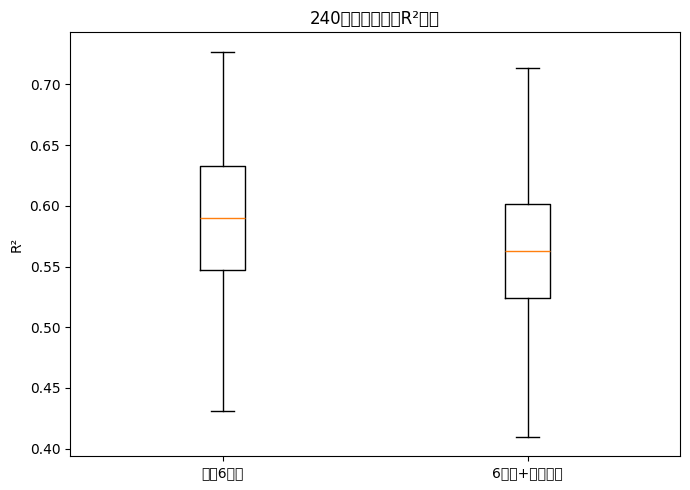

In [7]:
plot_data = [
    baseline_metrics['R2'],
    spatial_metrics['R2'],
]
plt.figure(figsize=(7, 5))
plt.boxplot(plot_data, labels=['原始6特征', '6特征+空间特征'])
plt.ylabel('R²')
plt.title('240次随机划分的R²分布')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'R2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
comparison_predictions = df[['model_row', 'Old_index_1', 'smiles', TARGET]].copy()
comparison_predictions['baseline_mean_prediction_ln'] = baseline_pred
comparison_predictions['spatial_mean_prediction_ln'] = spatial_pred
comparison_predictions.to_csv(
    RESULT_DIR / 'mean_predictions_by_sample.csv',
    index=False,
    encoding='utf-8-sig',
)

final_model = XGBRegressor(random_state=0, **XGB_PARAMS)
final_model.fit(df[BASE_FEATURES + SPATIAL_FEATURES], df[TARGET])
joblib.dump(final_model, RESULT_DIR / 'xgboost_6_plus_spatial_full_model.joblib')

with open(RESULT_DIR / 'run_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'n_samples': len(df),
        'train_size': 728,
        'test_size': 128,
        'n_runs': N_RUNS,
        'base_features': BASE_FEATURES,
        'spatial_features': SPATIAL_FEATURES,
        'xgb_params': XGB_PARAMS,
    }, f, ensure_ascii=False, indent=2)

print('结果已保存到：', RESULT_DIR.resolve())


结果已保存到： C:\Users\6\Desktop\SJTU\MI Chemistry\4\tpaml_unified_output\task4_spatial_results
